In [24]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from TurPy import *
from params import make_params
from Helpers import modified_von_karman, fft2, generate_oneway_trip_hv_model, calculate_path

In [25]:
# ----------------------------
# Grid
# ----------------------------
N = 512
dx = 0.01
df = 1 / (N * dx)
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.linspace(-N//2, N//2 - 1, N, device=device) * dx
fx = torch.linspace(-N//2, N//2 - 1, N, device=device) * df
xx, yy = torch.meshgrid(x, x, indexing="ij")
fX, fY = torch.meshgrid(fx, fx, indexing="ij")
fR = torch.sqrt(fX**2 + fY**2)

# Turbulence Parameters
r0 = 0.5
L0 = 1.0
l0 = 0.01

# Phase screen parameters
screen = StaticPhaseScreen(
    device=device,
    sim_type="2d",
    fR=fR, fX=fX, fY=fY,
    xx=xx, yy=yy,
    dfx=df, dfy=df,
    psd_fn=modified_von_karman,
    L0=L0, l0=l0,
    subharmonics=True
)

# ----------------------------
# Monte Carlo experiment
# ----------------------------
N_mc = 5000


[TEST PASSED] Power Spectral Density inconsistent with error of [4.50467269e-07 2.53315505e-07 1.84984600e-07 ... 1.32868910e-10
 1.32183736e-10 1.30938080e-10]


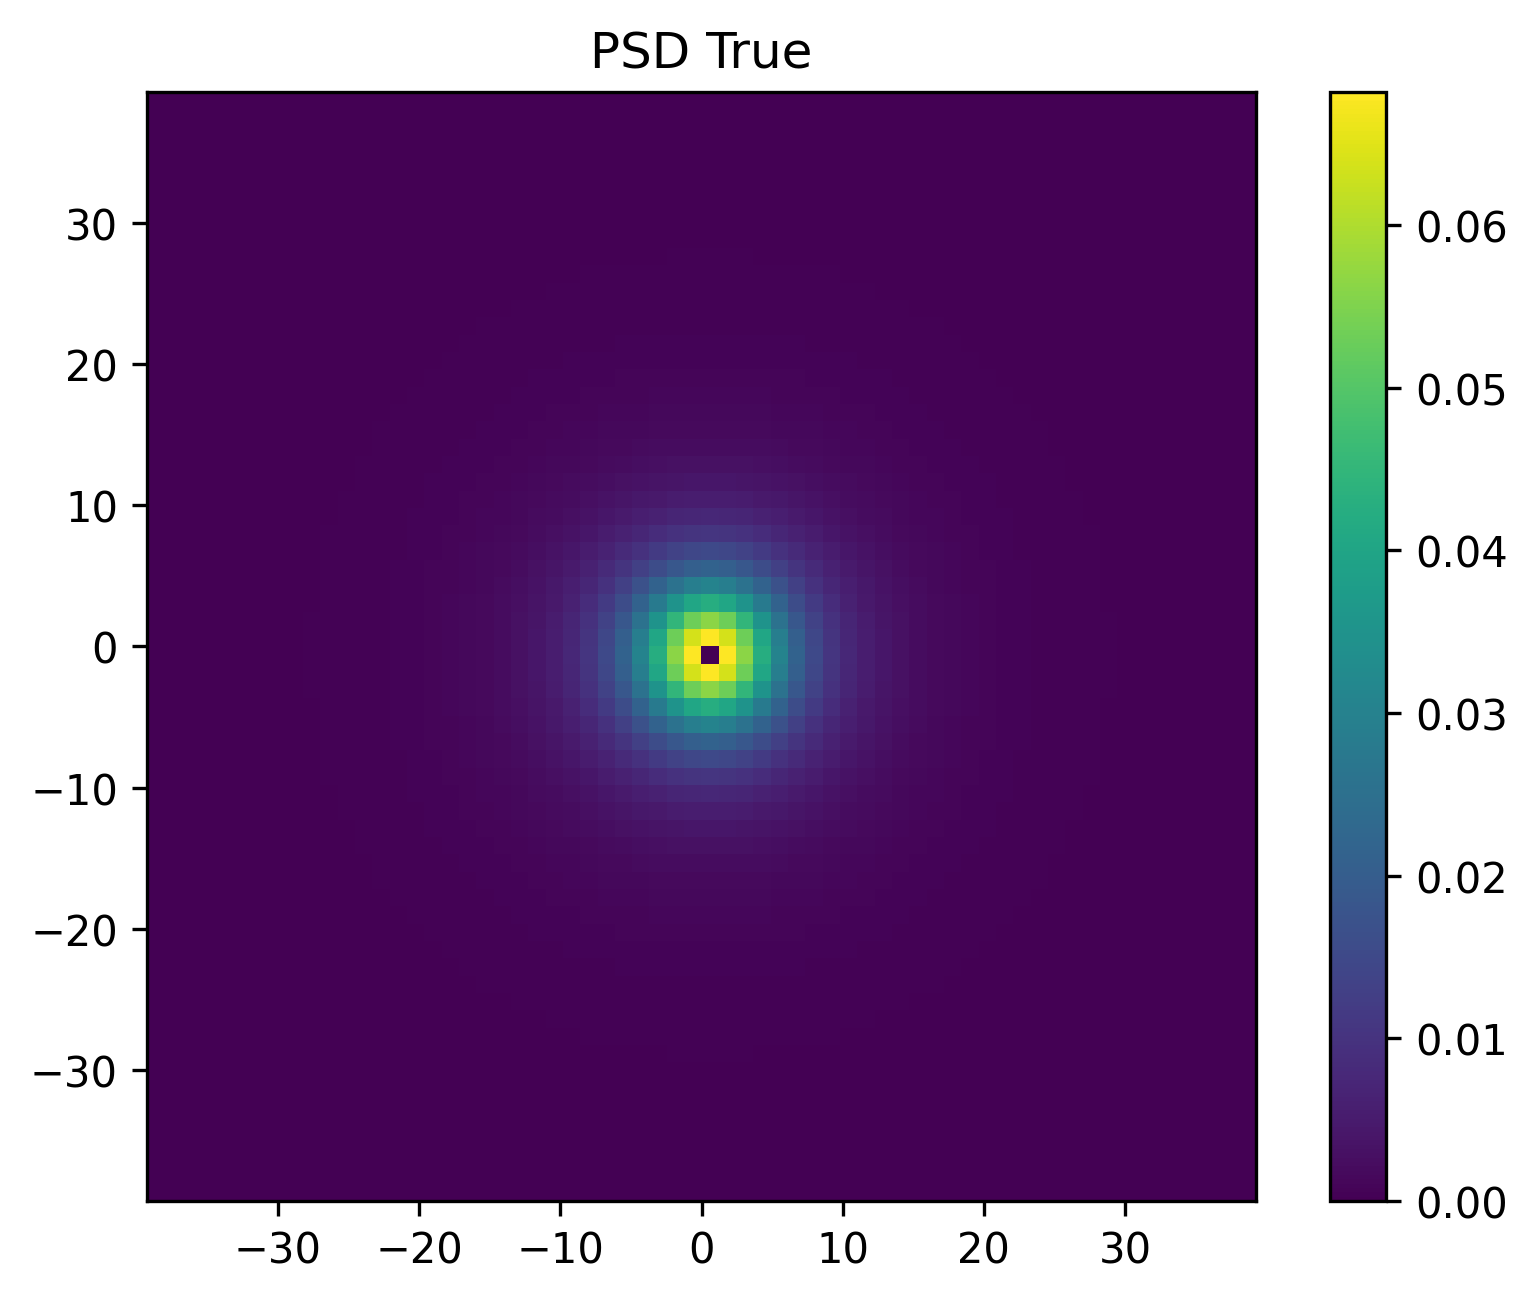

In [26]:
# TEST ONE: PSD Conservation
# Determine truth
psd_true = modified_von_karman(r0, fR, L0, l0)
psd_true[screen.fR == 0] = 0

# Setup up experimental sweep
psd_accum = torch.zeros_like(fR)
agg = 0
err = np.zeros(N_mc+1)

# Run trials
for n in range(N_mc+1):
    start = time.time()
    phi = screen.sample(r0)
    agg += (time.time() - start)
    phi_f = fft2(phi)
    psd_accum += (torch.abs(phi_f)**2)

    # Determine Error
    psd_mc = psd_accum / ((n + 1) * df ** 2)
    err[n] = torch.mean(torch.abs(psd_true - psd_mc.detach())**2).item()

    # # Plot intermediately
    # if (n) % 250 == 0:
    #     plt.figure(dpi=300)
    #     plt.imshow(psd_mc.cpu().numpy()[int(N//2-32):int(N//2+32), int(N//2-32):int(N//2+32)], extent=[-32*df*2*np.pi, 32*df*2*np.pi, -32*df*2*np.pi, 32*df*2*np.pi])
    #     plt.title(f'PSD Monte Carlo {n}')
    #     plt.colorbar()
    #     plt.show()
        
# Calculate power
psd_mc = psd_accum / ((N_mc + 1) * df ** 2)

if err[-1] >= 0.01:
    print(f'[TEST FAILED] Power Spectral Density inconsistent with error of {err}')
else:
    print(f'[TEST PASSED] Power Spectral Density inconsistent with error of {err}')

plt.figure(dpi=300)
plt.imshow(psd_true.cpu().numpy()[int(N//2-32):int(N//2+32), int(N//2-32):int(N//2+32)], extent=[-32*df*2*np.pi, 32*df*2*np.pi, -32*df*2*np.pi, 32*df*2*np.pi])
plt.title('PSD True')
plt.colorbar()
plt.show()


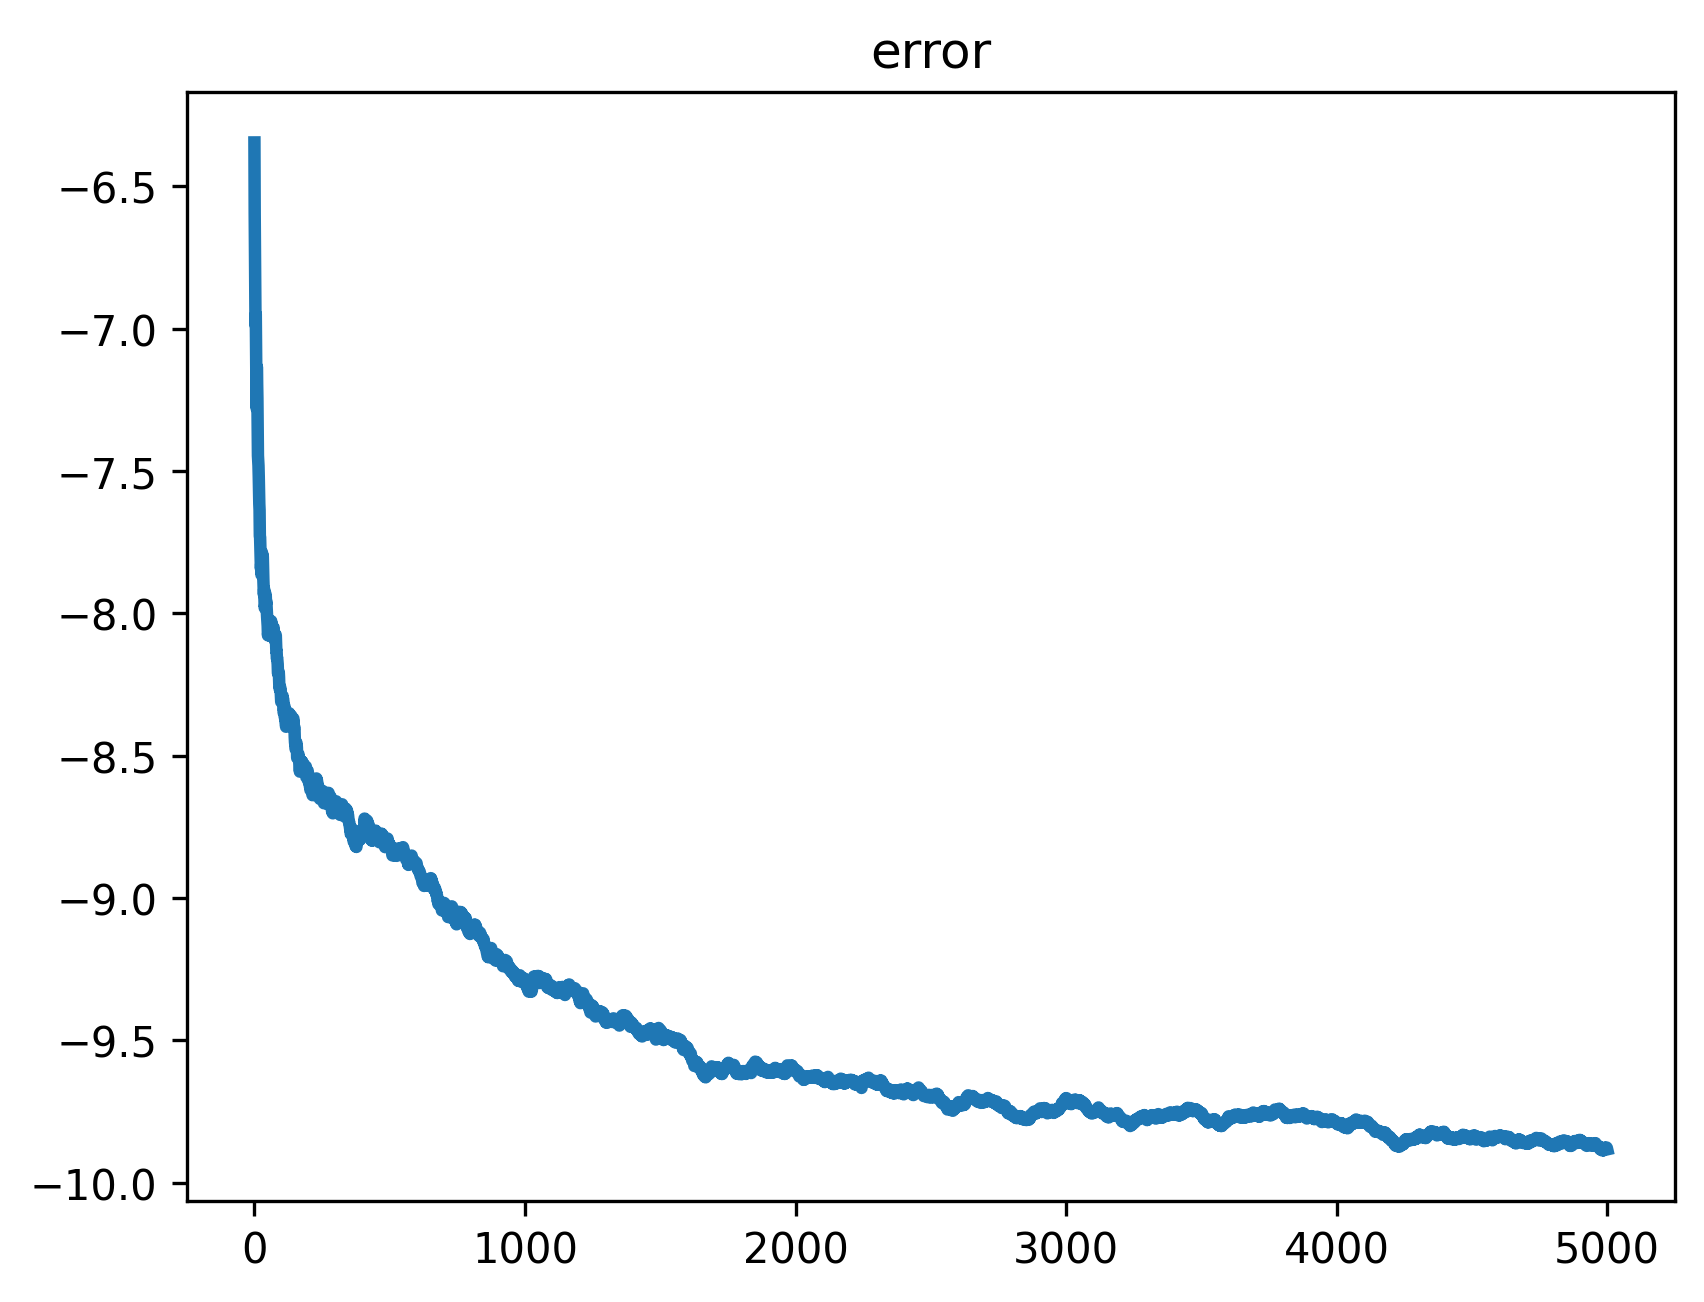

[4.50467269e-07 2.53315505e-07 1.84984600e-07 ... 1.32868910e-10
 1.32183736e-10 1.30938080e-10]


In [27]:
plt.figure(dpi=300)
plt.plot(np.log10(err), linewidth=3)
plt.title('error')
plt.show()

print(err)

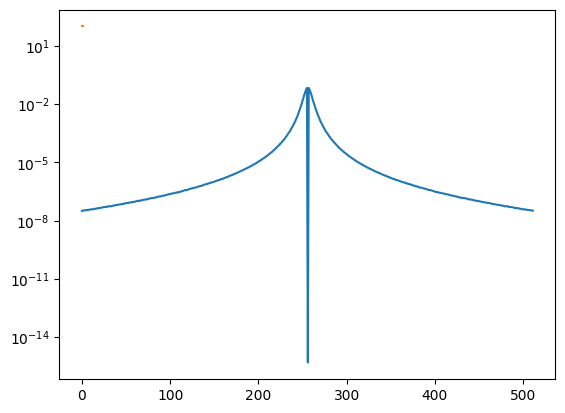

In [28]:
cross = psd_mc[N//2, :].cpu().numpy()

plt.figure()
plt.semilogy(cross)
plt.semilogy([1/l0, 1/l0])

[TEST PASSED] Phase variance slope ≈ -1.667 (expected −5/3 ≈ -1.667)


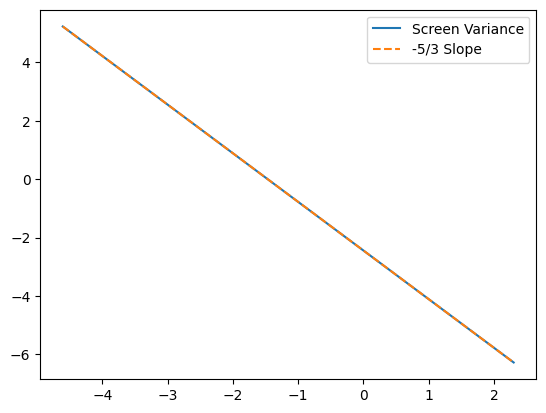

In [29]:
# TEST 2: Check if variance across phase screen is consistent with power law
r0_min = 0.01
r0_max = 10
r0_vals = np.exp(np.linspace(np.log(r0_min), np.log(r0_max), 100))
vars = []

# Sweep through generate screen vars
for r0 in r0_vals:
    phi = screen.sample(float(r0), seed=123)
    vars.append(phi.var().item())

# Send to log scale
log_r0 = torch.log(torch.tensor(r0_vals, dtype=torch.float64))
log_var = torch.log(torch.tensor(vars, dtype=torch.float64))

# Perform reduction
A = torch.stack([log_r0, torch.ones_like(log_r0)], dim=1)
sol = torch.linalg.lstsq(A, log_var).solution
slope = sol[0].item()

# Test
err = np.abs(slope + 5/3)
if err < 0.1:
    print(f"[TEST PASSED] Phase variance slope ≈ {slope:.3f} (expected −5/3 ≈ {-5/3:.3f})")
else:
    print(f"[TEST FAILED] Phase variance slope ≈ {slope:.3f} (expected −5/3 ≈ {-5/3:.3f})")

# Plot
idx = np.argmin(log_var)
x0 = log_r0[idx].item()
y0 = log_var[idx].item()
slope = -5/3
x_line = np.linspace

# Make reference line
log_var_ref = slope * (log_r0 - x0) + y0

plt.figure()
plt.plot()
plt.plot(log_r0, log_var, label='Screen Variance')
plt.plot(log_r0, log_var_ref, linestyle="--", label='-5/3 Slope')
plt.legend()
plt.show()

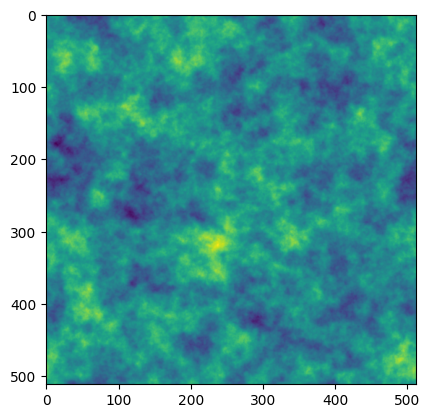

In [30]:
plt.figure()
plt.imshow(screen.sample(float(r0)).cpu().numpy(), cmap='viridis')

In [31]:
# TEST 3: POWER CONSERVATION

# Load params
params = make_params()
params["field_size"] = (512, 512)
params["dx"] = 0.001
params["absorb_boundary"] = False  # turn off absorbing boundary for test NOTE: ensure array large enough for Gaussian growth
params["strong_mode"] = False
params["L0"] = L0
params["l0"] = l0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Define Gaussian
wavelength = params["wavelength"] # wavelength
k = 2*np.pi / wavelength
theta = 0.05e-3  # divergence
w0 = wavelength / (torch.pi * theta)

# Define function for waist calculation
def beam_theory(w0, theta, R, Cn2, wavelength):
    w_fs = torch.sqrt(w0**2 + (theta*R.max())**2)
    rytov = 3.27 * (2 * np.pi / wavelength) ** (7 / 6) * R.max() ** (5 / 6) *  torch.trapz(Cn2 * (1 - R / R.max()) ** (5 / 3), R)
    fres_ratio = (2 * R.max() / ((2*torch.pi/wavelength) * w_fs ** 2))  # fresnel ratio
    return w_fs * torch.sqrt(1 + 4/3 * rytov**(6/5) * fres_ratio)  # strong model assumption

# Define Turbulence
A = 1e-12
R = torch.linspace(1, 500, 1000)
Cn2 = generate_oneway_trip_hv_model(A=A, W=21, R=R)
rytov = 3.27 * (2 * np.pi / wavelength) ** (7 / 6) * R.max() ** (5 / 6) *  torch.trapz(Cn2 * (1 - R / R.max()) ** (5 / 3), R)
r0_path = (0.423 * (2 * np.pi / wavelength) ** 2 * torch.trapz(Cn2, R))**(-3/5)
dr, r0 = calculate_path(params, R=R, Cn2=Cn2)

print(f'Generating simulation with Rayleigh Length of {np.pi*w0**2/wavelength}, r0 of {r0_path}, and Rytov Variance of {rytov}')

# Sanity check
turb = beam_theory(w0, theta, R, Cn2, wavelength)

# Make TurPy
wt = TurPy(params=params).to(DEVICE)

# Sanity check
w_turb = beam_theory(w0, theta, R, Cn2, wavelength)
print(w_turb, wt.xx.max())
#assert wt.xx.max() > beam_theory(w0, theta, R, Cn2, wavelength), "Simulation size too small"


# Make Gaussian
amplitude = torch.exp(-(wt.xx**2 + wt.yy**2) / w0**2).to(torch.cfloat).to(DEVICE)
amplitude = amplitude / amplitude.sum()
p_in = torch.sum(torch.abs(amplitude.clone())**2)
output = wt(amplitude, dr=dr, r0=r0)
free_space = wt(amplitude, dr=dr, r0=None)
p_out = torch.sum(torch.abs(output.clone())**2)

# Test
err = torch.abs(p_in - p_out)

if err < 1e-5:
    print(f"[TEST PASSED] Power conserved with loss of {err:.10f}")
else:
    print(f"[TEST FAILED] Power conserved with loss of {err:.10f}")


maximum step size support by this simulation is = 360.9022045670941 m
Generating simulation with Rayleigh Length of 135.4726875598213, r0 of 0.0126704266294837, and Rytov Variance of 3.2516798973083496
tensor(0.0400) tensor(0.2550, device='cuda:0')
[TEST PASSED] Power conserved with loss of 0.0000000044


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_34500\2460922591.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(free_space.cpu())**2)
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_34500\2460922591.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(output.cpu())**2)
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_34500\2460922591.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(amplitude.cpu())**2)


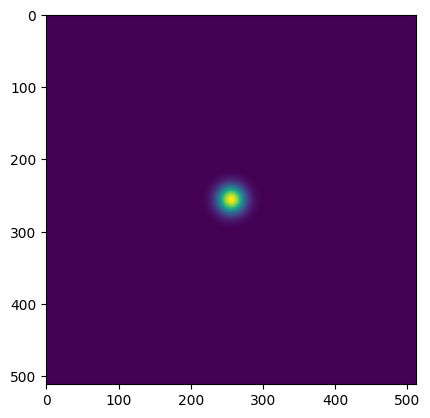

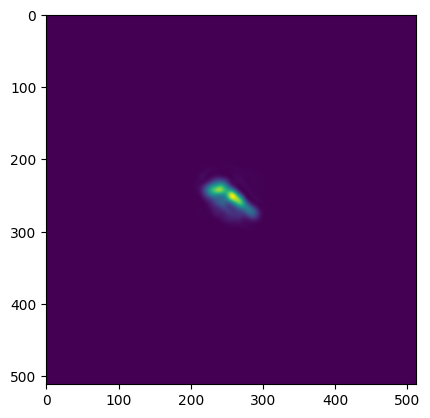

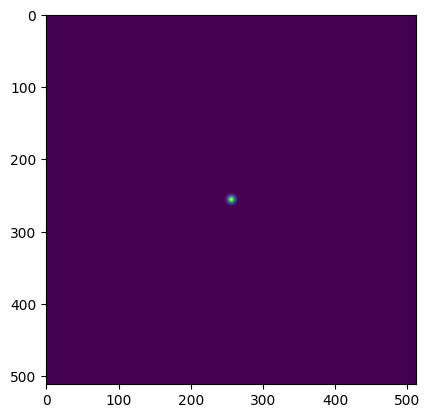

In [32]:
plt.figure()
plt.imshow(np.abs(free_space.cpu())**2)
plt.figure()
plt.imshow(np.abs(output.cpu())**2)
plt.figure()
plt.imshow(np.abs(amplitude.cpu())**2)

In [33]:
# test = wt.logamp_screen.sample_logamp(5)
# test_p = wt.phase_screen.sample(5)

# test_e = torch.exp(test).detach().cpu()

# plt.figure()
# plt.imshow(test.detach().cpu().numpy())
# plt.colorbar()

# plt.figure()
# plt.imshow(np.real(test_e))
# plt.colorbar()

In [34]:
# TEST 4: GAUSSIAN BROADENING

# For averaging
start = time.time()
I_av = 0
r2 = wt.xx**2 + wt.yy**2

# MC loop
for _ in range(N_mc):
    with torch.no_grad():
        output = wt(amplitude, dr=dr, r0=r0)
        I = torch.abs(output)**2
        I_av += I
end = time.time()


# average
I_av /= N_mc
width = torch.sqrt(2*torch.sum(r2 * I_av) / torch.sum(I_av))

# Test
err = torch.abs(turb - width) / turb * 100

if err < 5:
    print(f"[TEST PASSED] Turbulent-Broadened waist with error of {err:.2f} %")
else:
    print(f"[TEST FAILED] Turbulent-Broadened waist with error of {err:.2f} %")

print(f'Average Iteration Time of {(end - start) / N_mc} s')

plt.figure()
plt.imshow(I.cpu().numpy())
plt.show()

KeyboardInterrupt: 

In [ ]:
def calculate_plane_wave_scintillation(rytov):
    return np.exp((0.49*rytov) / (1 + 1.11*rytov**(6/5)) + 0.51*rytov / (1 + 0.69 * rytov**(6/5))**(5/6)) - 1

In [35]:
# TEST 4: Plane Wave Scintillation (should be close to rytov under weak conditions)
R = torch.linspace(0, 20000, 10000) # Fixed link distance
N_mc = 3000
A_vec = torch.logspace(-17.5, -13.5, 20) # variable ground level turb

# Load params
params = make_params()
params["field_size"] = (1024, 1024)
params["dx"] = 0.003
params["absorb_boundary"] = False  # turn off absorbing boundary for test NOTE: ensure array large enough for Gaussian growth
params["strong_mode"] = False
params["L0"] = L0
params["l0"] = l0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Make TurPy
wt = TurPy(params=params).to(DEVICE)

# For statistics
rytov_vec = np.ones_like(A_vec)
r0_vec = np.ones_like(A_vec)
scint_weak = np.ones_like(A_vec)
scint_strong = np.ones_like(A_vec)
scint_exp = np.ones_like(A_vec)
on_axis = torch.zeros_like(R)

# Turn back on absorbing boundaries
params["absorb_boundary"] = True
params["boundary_frac"] = 0.05
# Make TurPy
wt = TurPy(params=params).to(DEVICE)

# Define plane wave intensity
plane = torch.ones_like(wt.xx).to(torch.cfloat).to(DEVICE)

# MC loop
for i, A in enumerate(A_vec):
    # Setup parameters
    # Cn2 = generate_oneway_trip_hv_model(A=A, W=21, R=R)
    # Do horizontal instead of vertical
    Cn2 = torch.ones_like(R)*A
    dr, r0 = calculate_path(params, R=R, Cn2=Cn2, rytov_limit=100)
    print(dr)

    rytov_vec[i] = 3.27 * (2 * np.pi / wavelength) ** (7 / 6) * R.max() ** (5 / 6) *  torch.trapz(Cn2 * (1 - R / R.max()) ** (5 / 3), R)
    r0_vec[i] = (0.423 * (2 * np.pi / wavelength) ** 2 * torch.trapz(Cn2, R))**(-3/5)
    print(rytov_vec[i])

    # New stack to track
    I_stack = []
    for n in range(N_mc):
        with torch.no_grad():
            output = wt(plane, dr=dr, r0=r0)
            I = torch.abs(output)**2

            # Get the mean value across the map
            I_stack.append(I)

    # Calculate scintillation
    I_ens = torch.stack(I_stack)
    I_ens = I_ens[:, params["field_size"][0]//2 - params["field_size"][0]//3:params["field_size"][0]//2 + params["field_size"][0]//3, params["field_size"][1]//2 - params["field_size"][1]//3:params["field_size"][1]//2 + params["field_size"][1]//3]
    mean_I = I_ens.mean(0, )
    var_I = I_ens.var(0, unbiased=True)
    scint_map = var_I / (mean_I**2)
    scint_exp[i] = scint_map.max()

    # del I_stack  # For safety

    # Calculate theory
    scint_weak[i] = 1.23 * rytov_vec[i]
    scint_strong[i] = calculate_plane_wave_scintillation(rytov_vec[i])

maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.023636252
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.038379997
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.062320545
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.10119465
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.16431753
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.266815
maximum step size support by this simulation is = 6496.240499359759 m
tensor([6494.6494, 6494.6494, 6494.6504,  516.0508])
0.43324798
maximum step size support by this simulation is = 6496.240499

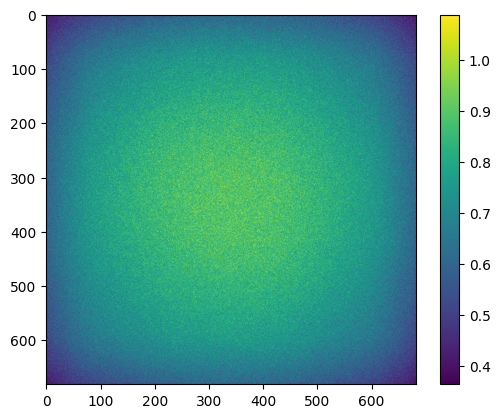

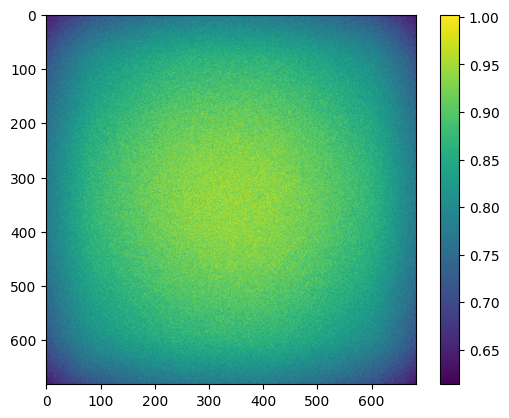

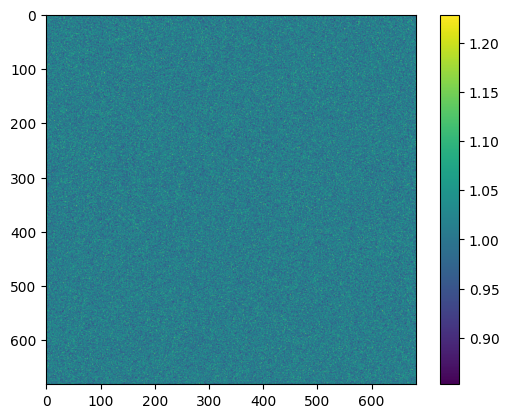

In [36]:
plt.figure()
plt.imshow(var_I.cpu().numpy())
plt.colorbar()

plt.figure()
plt.imshow(mean_I.cpu().numpy())
plt.colorbar()

plt.figure()
plt.imshow(scint_map.cpu().numpy())
plt.colorbar()

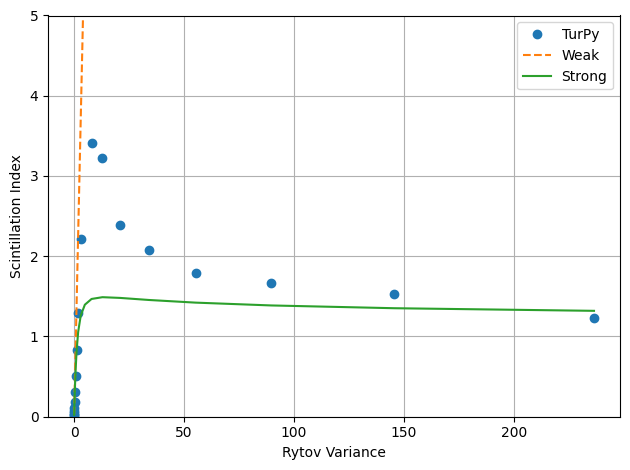

In [37]:
entries = [1, 3*len(rytov_vec)//4, -2, -1]

plt.figure()
ax1 = plt.gca()
ax1.plot(rytov_vec, scint_exp, "o", label="TurPy")
ax1.plot(rytov_vec, scint_weak, "--", label="Weak")
ax1.plot(rytov_vec, scint_strong, "-", label="Strong")
ax1.set_xlabel("Rytov Variance")
ax1.set_ylim([0, 5])
ax1.set_ylabel("Scintillation Index")
ax1.legend()
ax1.grid(True)

# ax2 = ax1.twiny() 
# ax2.set_xlim(ax1.get_xlim())
# ax2.set_xticks(rytov_vec[entries]) # Assumed rytov_vec matches your primary data
# ax2.set_xticklabels([f'{fried:.1e}' for fried in r0_vec[entries]])
# ax2.set_xlabel('Fried Parameter ($r_0$)') # Optional: label for the top axi

plt.tight_layout()
plt.show()

In [ ]:
# TEST 5: On-Axis Scintillation of a Gaussian
on_axis = torch.tensor(on_axis)

# Mean and variance
mean_I_on = on_axis.mean()
var_I_on = on_axis.var(unbiased=False)

# Scintillation calculation
scint_on = var_I_on / mean_I_on**2

# Theory
theory_scint = rytov * (w0**2 / (w0**2 + 2*R.max()**2 / (k**2*r0_path**2)))

print(f'On-axis scintillation of {scint_on}')
print(theory_scint)


On-axis scintillation of nan
tensor(0.0010)


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_34500\2808327859.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  on_axis = torch.tensor(on_axis)


In [ ]:
# TEST 5: Full Scintillation
I_stack = torch.stack(I_stack)

# Mean and Variance
mean_I_map = I_stack.mean(0)
var_I_map = I_stack.var(0, unbiased=False)

# Scintillation calculation
scint_map = var_I_map / mean_I_map**2
scint_map[r2 > turb**2] = 0 # Filter outside turbulent waist

plt.figure()
plt.imshow(scint_map.cpu().numpy())
plt.colorbar()
plt.show()

IndexError: The shape of the mask [512, 512] at index 0 does not match the shape of the indexed tensor [1024, 1024] at index 0

In [ ]:
plt.figure()
plt.imshow(I_stack[3].detach().cpu().numpy())
plt.colorbar()
plt.show()

In [ ]:
screen = wt.phase_screen.sample(0.5)
test = torch.abs(torch.exp(wt.logamp_screen.sample(0.5) + 1j*screen))

plt.figure()
plt.imshow(test.detach().cpu().numpy())
plt.colorbar()
plt.show()